# Análisis del flow-matching de pi0 — ¿hay clusters?

Analiza el CSV de denoising (`output/pi0_denoise/denoise_log.csv`) generado por
`models/Pi_zero/patches.py`. Cada fila es el vector `x_t` en un paso del
flow-matching; `iteration=0` es el ruido inicial y la última iteración de cada
`call` es la **acción final**.

**Objetivo:** ver si, dado el *mismo input*, las acciones finales de las distintas
corridas forman **clusters claros** (señal de una política multimodal).

**Método:** estado final por corrida → reducción a 2D (PCA y t-SNE) → clustering
(KMeans) con *silhouette* para cuantificar qué tan marcados son los clusters.

> Ejecuta este notebook con el entorno conda **`tipico`** (necesita `pandas`,
> `scikit-learn` y `matplotlib`). Si el kernel no aparece seleccionado, elígelo
> a mano (Kernel → Change Kernel).

## 0. Toolkit — clases reutilizables

Todo el análisis está encapsulado en cuatro clases (`DenoiseLog`, `ClusterScan`,
`FlowMatchingAnalyzer`, `PerStepStudy`). **Ejecuta la siguiente celda una vez** y
el resto del notebook queda en llamadas de una línea. Si cambias algo del análisis,
edítalo aquí en un solo lugar.

In [51]:
"""Toolkit de analisis del flow-matching de pi0.

Todo el codigo del notebook vive aqui, en clases reutilizables. Ejecuta esta
celda UNA vez y luego el resto del notebook son llamadas de una linea:

    log   = DenoiseLog.load(CSV_PATH)     # carga y consulta del CSV
    fm    = FlowMatchingAnalyzer(log)     # PCA / t-SNE / UMAP + clustering + plots
    study = PerStepStudy(log)             # mismo analisis, pero step por step

Clases:
  - DenoiseLog           : carga el CSV y extrae las acciones finales (por call/step).
  - ClusterScan          : barre k con KMeans, elige el mejor por silhouette y da veredicto.
  - FlowMatchingAnalyzer : analisis global de las acciones finales (reduccion 2D + clusters + GIF + std).
  - PerStepStudy         : repite el analisis de clusters para cada step del entorno.
"""
import os
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# --- Animacion del denoising (compartida por el GIF global y los GIF por step) ---
def _render_denoising_gif(proj, path, title_prefix="Flow-matching", fps=3):
    """Guarda un GIF del denoising sobre un plano 2D ya proyectado.

    `proj` es un DataFrame con columnas: call, iteration, z0, z1, cluster. Un frame
    por iteracion; cada punto se colorea por su cluster final. Devuelve `path`.
    """
    import matplotlib.animation as animation

    iters = sorted(proj["iteration"].unique())
    pad0 = 0.05 * (proj["z0"].max() - proj["z0"].min() + 1e-9)
    pad1 = 0.05 * (proj["z1"].max() - proj["z1"].min() + 1e-9)

    fig, ax = plt.subplots(figsize=(6, 6))
    scat = ax.scatter([], [], s=50, alpha=0.85, cmap="tab10", c=[],
                      vmin=proj["cluster"].min(), vmax=max(proj["cluster"].max(), 1))
    ax.set_xlim(proj["z0"].min() - pad0, proj["z0"].max() + pad0)
    ax.set_ylim(proj["z1"].min() - pad1, proj["z1"].max() + pad1)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    title = ax.set_title("")

    def update(it):
        g = proj[proj["iteration"] == it]
        scat.set_offsets(g[["z0", "z1"]].to_numpy())
        scat.set_array(g["cluster"].to_numpy())
        t = "ruido inicial" if it == iters[0] else ("accion final" if it == iters[-1] else "")
        title.set_text(f"{title_prefix} - iteracion {it}/{iters[-1]}  {t}")
        return scat, title

    anim = animation.FuncAnimation(fig, update, frames=iters, interval=300, blit=False)
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    anim.save(path, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    return path


# --- Datos ------------------------------------------------------------------
@dataclass
class DenoiseLog:
    """CSV de denoising de pi0. Cada fila = vector x_t en un paso del flow-matching.

    `iteration=0` es el ruido inicial y la ultima iteracion de cada `call` es la
    accion final (tiempo t ~ 0). El vector v0..vK es (chunk_size, max_action_dim)
    aplanado: la coordenada i corresponde a (chunk_step = i // max_action_dim,
    dim = i % max_action_dim).
    """
    df: pd.DataFrame
    feat_cols: list

    @classmethod
    def load(cls, path):
        assert os.path.exists(path), f"No encuentro el CSV en {path!r}. Ajusta CSV_PATH."
        df = pd.read_csv(path)
        feat_cols = [c for c in df.columns if c.startswith("v") and c[1:].isdigit()]
        return cls(df=df, feat_cols=feat_cols)

    @property
    def n_calls(self):
        return self.df["call"].nunique()

    @property
    def steps(self):
        return sorted(self.df["step"].unique())

    def finals(self, step=None):
        """DataFrame con la ULTIMA iteracion de cada call (la accion final).

        Con `step` filtra al estado del entorno indicado; sin el, usa todo el CSV.
        """
        sub = self.df if step is None else self.df[self.df["step"] == step]
        final_iter = sub.groupby("call")["iteration"].transform("max")
        return sub[sub["iteration"] == final_iter].sort_values("call").reset_index(drop=True)

    def final_matrix(self, step=None):
        """Matriz (n_calls, n_features) de las acciones finales."""
        return self.finals(step)[self.feat_cols].to_numpy(dtype=float)


# --- Clustering -------------------------------------------------------------
@dataclass
class ClusterScan:
    """Barrido de KMeans sobre una matriz ya en el espacio a clusterizar.

    Prueba k en [2..kmax], se queda con el de mejor silhouette y traduce el score
    a un veredicto (regla practica: >0.50 fuerte, 0.25-0.50 debil, <0.25 unimodal).
    """
    silhouettes: dict          # {k: silhouette_score}
    best_k: object             # int, o np.nan si no aplica
    best_sil: object           # float redondeado, o np.nan
    labels: np.ndarray         # etiqueta de cluster por muestra
    verdict: str               # "fuerte" | "debil" | "unimodal" | "pocas muestras"

    @classmethod
    def run(cls, M, kmax=6):
        n = M.shape[0]
        empty = cls({}, np.nan, np.nan, np.zeros(n, dtype=int), "pocas muestras")
        if n < 4 or M.shape[1] == 0:
            return empty
        ks = [k for k in range(2, kmax + 1) if k < n]
        sil = {k: silhouette_score(
                   M, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(M))
               for k in ks}
        if not sil:
            return empty
        best_k = max(sil, key=sil.get)
        best_sil = sil[best_k]
        labels = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit_predict(M)
        verdict = "fuerte" if best_sil > 0.50 else "debil" if best_sil > 0.25 else "unimodal"
        return cls(sil, best_k, round(best_sil, 3), labels, verdict)


# --- Analisis global --------------------------------------------------------
class FlowMatchingAnalyzer:
    """Analiza si las acciones finales de pi0 forman clusters (politica multimodal).

    Prepara una vez las acciones finales: quita dimensiones constantes (padding /
    sin variacion) y las estandariza. Sobre eso ofrece PCA/t-SNE/UMAP, clustering
    y las visualizaciones (scatter, trayectorias del denoising y GIF).
    """

    def __init__(self, log: DenoiseLog):
        self.log = log
        self.finals = log.finals()
        X = self.finals[log.feat_cols].to_numpy(dtype=float)
        self.nonconst = X.std(axis=0) > 1e-8          # dims con variacion
        self.X = X[:, self.nonconst]
        self.n = self.X.shape[0]
        self.scaler = StandardScaler().fit(self.X)
        self.Xs = self.scaler.transform(self.X)       # estandarizada (media 0, var 1)
        # caches perezosos
        self._pca = self._Z = self._scan = self._proj = None

    # ---- reducciones a 2D ----
    def pca(self):
        """PCA 2D de las acciones finales (cacheada). Devuelve (Z, modelo_pca)."""
        if self._Z is None:
            self._pca = PCA(n_components=2, random_state=0)
            self._Z = self._pca.fit_transform(self.Xs)
        return self._Z, self._pca

    def tsne(self):
        """t-SNE 2D. Devuelve (embedding, perplexity usada)."""
        perp = max(2, min(30, (self.n - 1) // 3))
        Zt = TSNE(n_components=2, perplexity=perp, init="pca",
                  random_state=0).fit_transform(self.Xs)
        return Zt, perp

    def umap(self):
        """UMAP 2D. Devuelve (embedding, reducer). Requiere umap-learn."""
        try:
            import umap
        except ImportError as e:
            raise ImportError(
                "Falta 'umap-learn' en el entorno 'tipico'. Instala con:  pip install umap-learn"
            ) from e
        nn = max(2, min(15, self.n - 1))              # n_neighbors < n_samples
        reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1, random_state=0)
        return reducer.fit_transform(self.Xs), reducer

    # ---- clustering ----
    def kmeans(self, kmax=6):
        """ClusterScan sobre las finales estandarizadas (cacheado)."""
        if self._scan is None:
            self._scan = ClusterScan.run(self.Xs, kmax=kmax)
        return self._scan

    # ---- proyeccion de TODAS las iteraciones (para trayectorias / GIF) ----
    def _projection_all(self):
        if self._proj is None:
            Xall = self.log.df[self.log.feat_cols].to_numpy(dtype=float)[:, self.nonconst]
            Zall = PCA(n_components=2, random_state=0).fit_transform(self.scaler.transform(Xall))
            proj = self.log.df[["call", "iteration"]].copy()
            proj["z0"], proj["z1"] = Zall[:, 0], Zall[:, 1]
            self._proj = proj
        return self._proj

    # ---- plots ----
    def plot_pca(self):
        Z, pca = self.pca()
        evr = pca.explained_variance_ratio_
        print("varianza explicada:", evr.round(3), "-> total 2D:", round(evr.sum(), 3))
        plt.figure(figsize=(6, 5))
        plt.scatter(Z[:, 0], Z[:, 1], s=45, alpha=0.85)
        plt.xlabel(f"PC1 ({evr[0]:.0%})"); plt.ylabel(f"PC2 ({evr[1]:.0%})")
        plt.title("Acciones finales de pi0 (PCA 2D)")
        plt.tight_layout(); plt.show()

    def plot_kmeans(self, kmax=6):
        scan = self.kmeans(kmax)
        Z, _ = self.pca()
        print("silhouette por k:", {k: round(v, 3) for k, v in scan.silhouettes.items()})
        if scan.silhouettes:
            print(f"mejor k = {scan.best_k}  (silhouette = {scan.best_sil:.3f})")
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        if scan.silhouettes:
            ax[0].plot(list(scan.silhouettes), list(scan.silhouettes.values()), "o-")
            ax[0].axhline(0.25, ls="--", c="gray", lw=0.8)
            ax[0].axhline(0.50, ls="--", c="gray", lw=0.8)
            ax[0].set_xlabel("k (nº de clusters)"); ax[0].set_ylabel("silhouette")
            ax[0].set_title("Calidad de cluster vs k")
        ax[1].scatter(Z[:, 0], Z[:, 1], c=scan.labels, cmap="tab10", s=45, alpha=0.9)
        ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
        ax[1].set_title(f"KMeans k={scan.best_k} sobre PCA 2D")
        plt.tight_layout(); plt.show()

    def plot_tsne(self, kmax=6):
        if self.n < 5:
            print("Muy pocas muestras para t-SNE (n =", self.n, ")."); return
        labels = self.kmeans(kmax).labels
        Zt, perp = self.tsne()
        plt.figure(figsize=(6, 5))
        plt.scatter(Zt[:, 0], Zt[:, 1], c=labels, cmap="tab10", s=45, alpha=0.9)
        plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
        plt.title(f"Acciones finales (t-SNE, perplexity={perp})")
        plt.tight_layout(); plt.show()

    def plot_trajectories(self):
        proj = self._projection_all()
        plt.figure(figsize=(7, 6))
        for _, g in proj.groupby("call"):
            g = g.sort_values("iteration")
            plt.plot(g["z0"], g["z1"], "-", color="gray", alpha=0.3, lw=1)
        ini = proj[proj["iteration"] == 0]
        fin = proj.loc[proj.groupby("call")["iteration"].idxmax()]
        plt.scatter(ini["z0"], ini["z1"], s=25, c="tab:red",  alpha=0.7, label="ruido inicial")
        plt.scatter(fin["z0"], fin["z1"], s=50, c="tab:blue", alpha=0.9, label="acción final")
        plt.legend(); plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.title("Denoising: de ruido (rojo) a acción final (azul)")
        plt.tight_layout(); plt.show()

    def plot_umap(self, kmax=6):
        U, _ = self.umap()
        scan = ClusterScan.run(U, kmax=kmax)
        print("silhouette (UMAP) por k:", {k: round(v, 3) for k, v in scan.silhouettes.items()})
        if scan.silhouettes:
            print(f"mejor k = {scan.best_k}  (silhouette = {scan.best_sil:.3f})")
        plt.figure(figsize=(6, 5))
        plt.scatter(U[:, 0], U[:, 1], c=scan.labels, cmap="tab10", s=50, alpha=0.9)
        plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
        plt.title(f"Acciones finales — UMAP + KMeans (k={scan.best_k})")
        plt.tight_layout(); plt.show()
        return U, scan

    def save_gif(self, path="output/pi0_denoise/flow_matching.gif", kmax=6, fps=3):
        """GIF del denoising en el plano PCA global; color = cluster final."""
        from IPython.display import Image

        proj = self._projection_all().copy()
        labels = self.kmeans(kmax).labels
        call_to_label = dict(zip(self.finals["call"].to_numpy(), labels))
        proj["cluster"] = proj["call"].map(call_to_label).fillna(0).astype(int)
        _render_denoising_gif(proj, path, title_prefix="Flow-matching", fps=fps)
        print("GIF guardado en:", path)
        return Image(filename=path)

    # ---- desviacion estandar por coordenada (no-padding) ----
    def std_report(self, path="output/pi0_denoise/std_por_coordenada.csv",
                   action_dim=7, max_action_dim=32, step=None):
        """CSV con la desviacion estandar por coordenada NO-padding de la accion final.

        El vector de accion es (chunk_size, max_action_dim) aplanado. pi0 rellena
        hasta `max_action_dim` (32) dims, pero el robot real usa solo `action_dim`
        (7 en LIBERO: 6 cartesianas + pinza); el resto de cada bloque de 32 son
        PADDING. Para cada coordenada real (no padding) calcula, SOBRE las acciones
        finales de las corridas (todas, o solo las de `step` si se indica):
          - std             : desviacion estandar de la coordenada.
          - pct_del_max_std : std como % del maximo std entre coordenadas.
          - pct_del_max_abs : std como % del |valor| maximo de esa coordenada
                              (variabilidad relativa a su magnitud tipica).
        Guarda el CSV en `path` y devuelve el DataFrame.

        Si `n_features` no es multiplo de `max_action_dim`, cae al criterio del resto
        del notebook: no-padding = dims con variacion (std > 1e-8).
        """
        Xf = self.log.final_matrix(step)                  # (n_calls, n_feat) SIN recortar
        n_feat = Xf.shape[1]

        if n_feat % max_action_dim == 0:
            chunk_of = np.arange(n_feat) // max_action_dim
            dim_of = np.arange(n_feat) % max_action_dim
            mask = dim_of < action_dim                    # coordenadas reales (no padding)
            chunk_size = n_feat // max_action_dim
        else:
            print(f"[aviso] n_feat={n_feat} no es multiplo de max_action_dim={max_action_dim}; "
                  "uso 'no constante' (std>1e-8) como criterio de no-padding.")
            mask = Xf.std(axis=0) > 1e-8
            chunk_of = np.full(n_feat, -1); dim_of = np.full(n_feat, -1); chunk_size = None

        idx = np.where(mask)[0]
        Xn = Xf[:, idx]
        std = Xn.std(axis=0)
        mean = Xn.mean(axis=0)
        max_abs = np.abs(Xn).max(axis=0)
        max_std = std.max() if std.size else np.nan
        pct_max_std = (100.0 * std / max_std) if max_std else np.zeros_like(std)
        with np.errstate(divide="ignore", invalid="ignore"):
            pct_max_abs = np.where(max_abs > 0, 100.0 * std / max_abs, 0.0)

        rep = pd.DataFrame({
            "coordenada": [f"v{i}" for i in idx],
            "indice": idx,
            "chunk_step": chunk_of[idx],
            "dim": dim_of[idx],
            "media": mean,
            "std": std,
            "pct_del_max_std": pct_max_std,
            "pct_del_max_abs": pct_max_abs,
        })
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        rep.to_csv(path, index=False)

        print("CSV guardado en:", path)
        print(f"coordenadas no-padding: {len(rep)} de {n_feat}  "
              f"(chunk_size={chunk_size}, action_dim={action_dim}, max_action_dim={max_action_dim})"
              + (f" | step={step}" if step is not None else ""))
        if std.size:
            print(f"std max = {max_std:.4f}  (coord {rep.loc[rep['std'].idxmax(), 'coordenada']})")
            print("\nTop-5 coordenadas por std:")
            print(rep.sort_values("std", ascending=False).head(5).to_string(index=False))
        return rep


# --- Estudio por step -------------------------------------------------------
class PerStepStudy:
    """Repite el analisis de clusters de las acciones finales, pero step por step.

    Para cada `step` toma sus acciones finales, quita dims constantes, estandariza
    y corre `ClusterScan`. La tabla resultante marca cada step como fuerte / debil
    / unimodal.
    """

    def __init__(self, log: DenoiseLog, kmax=6):
        assert "step" in log.df.columns, \
            "El CSV no tiene columna 'step'. Regenera con el barrido del notebook de pi0."
        self.log = log
        self.kmax = kmax
        self.steps = log.steps
        rows = [{"step": s, **self._analyze(s)} for s in self.steps]
        self.table = pd.DataFrame(rows).set_index("step")

    def _clean(self, step):
        """Acciones finales del step, sin dimensiones constantes."""
        Xraw = self.log.final_matrix(step)
        return Xraw[:, Xraw.std(axis=0) > 1e-8]

    def _analyze(self, step):
        Xr = self._clean(step)
        M = StandardScaler().fit_transform(Xr) if Xr.shape[1] else Xr
        scan = ClusterScan.run(M, kmax=self.kmax)
        return {"n": Xr.shape[0], "best_k": scan.best_k,
                "best_sil": scan.best_sil, "veredicto": scan.verdict}

    def _step_projection(self, step):
        """Proyecta TODAS las iteraciones del step a un PCA 2D propio (para el GIF).

        Ajusta escalado + PCA sobre las acciones FINALES del step (mismas dims que
        el analisis) y transforma todas las iteraciones. Colorea cada corrida por
        el cluster de su accion final. Devuelve el DataFrame proj, o None si el step
        no tiene datos suficientes.
        """
        sub = self.log.df[self.log.df["step"] == step]
        finals = self.log.finals(step)
        Xf = finals[self.log.feat_cols].to_numpy(dtype=float)
        nonconst = Xf.std(axis=0) > 1e-8
        Xf = Xf[:, nonconst]
        if Xf.shape[0] < 2 or Xf.shape[1] == 0:
            return None
        scaler = StandardScaler().fit(Xf)
        pca = PCA(n_components=2, random_state=0).fit(scaler.transform(Xf))

        bk = self.table.loc[step, "best_k"]
        if not np.isnan(bk) and bk >= 2:
            labels = KMeans(n_clusters=int(bk), n_init=10,
                            random_state=0).fit_predict(scaler.transform(Xf))
        else:
            labels = np.zeros(Xf.shape[0], dtype=int)
        call_to_label = dict(zip(finals["call"].to_numpy(), labels))

        Xall = sub[self.log.feat_cols].to_numpy(dtype=float)[:, nonconst]
        Zall = pca.transform(scaler.transform(Xall))
        proj = sub[["call", "iteration"]].copy()
        proj["z0"], proj["z1"] = Zall[:, 0], Zall[:, 1]
        proj["cluster"] = proj["call"].map(call_to_label).fillna(0).astype(int)
        return proj

    def save_gifs(self, out_dir="output/pi0_denoise/gifs_por_step", fps=3):
        """Genera un GIF del denoising por cada step y los guarda en `out_dir`.

        Archivos: `<out_dir>/step_00.gif`, `step_01.gif`, ... Devuelve la lista de
        rutas escritas.
        """
        os.makedirs(out_dir, exist_ok=True)
        paths = []
        for s in self.steps:
            proj = self._step_projection(s)
            if proj is None:
                print(f"step {s}: sin datos suficientes para el GIF, se omite.")
                continue
            path = os.path.join(out_dir, f"step_{int(s):02d}.gif")
            _render_denoising_gif(proj, path, title_prefix=f"Step {s}", fps=fps)
            print("  GIF step", s, "->", path)
            paths.append(path)
        print(f"\n{len(paths)} GIFs guardados en {out_dir}/")
        return paths

    def std_report(self, path="output/pi0_denoise/std_por_coordenada_por_step.csv",
                   action_dim=7, max_action_dim=32):
        """CSV de std por coordenada no-padding, UNA fila por (step, coordenada).

        Reusa FlowMatchingAnalyzer.std_report por cada step (sin escribir un CSV por
        step) y concatena todo en un unico CSV con columna `step`. Devuelve el
        DataFrame combinado.
        """
        import tempfile
        frames = []
        for s in self.steps:
            fm_s = FlowMatchingAnalyzer.__new__(FlowMatchingAnalyzer)  # sin PCA/escalado
            fm_s.log = self.log
            fm_s.finals = self.log.finals(s)
            rep = fm_s.std_report(path=os.path.join(tempfile.gettempdir(), "_tmp_std.csv"),
                                  action_dim=action_dim, max_action_dim=max_action_dim, step=s)
            rep.insert(0, "step", s)
            frames.append(rep)
        out = pd.concat(frames, ignore_index=True)
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        out.to_csv(path, index=False)
        print("\nCSV combinado (por step) guardado en:", path, f"({len(out)} filas)")
        return out

    def summary(self):
        print("Resumen por step:")
        print(self.table[["n", "best_k", "best_sil", "veredicto"]])
        multimodal = self.table.index[self.table["veredicto"].isin(["fuerte", "debil"])].tolist()
        print("\nSteps con indicios de multimodalidad:", multimodal if multimodal else "ninguno")
        return self.table

    def plot_silhouette(self):
        per = self.table
        fig, ax = plt.subplots(figsize=(max(6, 0.7 * len(per)), 4))
        vals = per["best_sil"].fillna(0).to_numpy()
        xs = np.arange(len(per))
        ax.bar(xs, vals, color="tab:blue", alpha=0.8)
        ax.axhline(0.50, ls="--", c="tab:green", lw=1, label="fuerte (0.50)")
        ax.axhline(0.25, ls="--", c="tab:orange", lw=1, label="debil (0.25)")
        ax.set_xticks(xs); ax.set_xticklabels(per.index)
        ax.set_xlabel("step"); ax.set_ylabel("mejor silhouette")
        ax.set_title("Multimodalidad de las acciones finales por step")
        for x, (_, r) in zip(xs, per.iterrows()):
            if not np.isnan(r["best_k"]):
                ax.text(x, (r["best_sil"] or 0) + 0.01, f"k={int(r['best_k'])}",
                        ha="center", va="bottom", fontsize=8)
        ax.legend(); plt.tight_layout(); plt.show()

    def plot_pca_grid(self):
        steps, per = self.steps, self.table
        ncols = min(4, len(steps))
        nrows = int(np.ceil(len(steps) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows), squeeze=False)
        for ax, s in zip(axes.ravel(), steps):
            Xr = self._clean(s)
            n = Xr.shape[0]
            if n < 2 or Xr.shape[1] == 0:
                ax.set_title(f"step {s} (n={n})"); ax.axis("off"); continue
            Xs = StandardScaler().fit_transform(Xr)
            Z = PCA(n_components=2, random_state=0).fit_transform(Xs)
            bk = per.loc[s, "best_k"]
            if not np.isnan(bk) and bk >= 2:
                lab = KMeans(n_clusters=int(bk), n_init=10, random_state=0).fit_predict(Xs)
            else:
                lab = np.zeros(n, dtype=int)
            ax.scatter(Z[:, 0], Z[:, 1], c=lab, cmap="tab10", s=25, alpha=0.85)
            ax.set_title(f"step {s} | sil={per.loc[s, 'best_sil']} | {per.loc[s, 'veredicto']}",
                         fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
        for ax in axes.ravel()[len(steps):]:
            ax.axis("off")
        plt.tight_layout(); plt.show()


print("Toolkit cargado: DenoiseLog, ClusterScan, FlowMatchingAnalyzer, PerStepStudy")

Toolkit cargado: DenoiseLog, ClusterScan, FlowMatchingAnalyzer, PerStepStudy


In [ ]:
"""Extension: reporte de std en UNIDADES FISICAS (cm / grados).

El CSV de denoising esta en espacio NORMALIZADO. Para pasarlo a cm hay que
des-normalizar con las stats del checkpoint (JSON generado UNA vez en el entorno
pizero con `python scripts/export_action_stats.py`) y luego aplicar la escala del
controlador OSC_POSE de LIBERO. Esta celda agrega `FlowMatchingAnalyzer.std_report_cm`.
"""
import json


def _load_action_stats(path):
    """Carga el JSON de stats de des-normalizacion (scripts/export_action_stats.py)."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"No encuentro las stats de normalizacion en {path!r}. Generalas UNA vez en "
            "el entorno pizero:  conda run -n pizero python scripts/export_action_stats.py")
    with open(path) as f:
        return json.load(f)


def _phys_conv(dim, stats):
    """(A, B, unidad) tal que valor_fisico = norm*A + B para la dim de accion `dim`.

    comando_OSC = norm*unnorm_std + unnorm_mean ; el controlador escala el comando a
    fisico: pos *0.05 m (-> cm, x100), ori *0.5 rad (-> grados). Asi A = unnorm_std*K
    y B = unnorm_mean*K, con K la escala a la unidad fisica de esa dimension.
    """
    ustd, umean = stats["unnorm_std"], stats["unnorm_mean"]
    sd = float(ustd[dim]) if dim < len(ustd) else 1.0
    mn = float(umean[dim]) if dim < len(umean) else 0.0
    cmax = stats.get("controller_output_max", [0.05, 0.05, 0.05, 0.5, 0.5, 0.5])
    pos = set(stats.get("pos_dims", [0, 1, 2]))
    ori = set(stats.get("ori_dims", [3, 4, 5]))
    grip = stats.get("gripper_dim", 6)
    if dim in pos:
        K, unit = cmax[dim] * 100.0, "cm"             # m -> cm
    elif dim in ori:
        K, unit = cmax[dim] * (180.0 / np.pi), "grados"  # rad -> deg
    elif dim == grip:
        K, unit = 1.0, "comando"
    else:
        K, unit = 1.0, "?"
    return sd * K, mn * K, unit


def std_report_cm(self, path="output/pi0_denoise/std_por_coordenada_cm.csv",
                  action_dim=7, max_action_dim=32, step=None,
                  stats_json="output/pi0_denoise/action_norm_stats.json"):
    """Como std_report pero en UNIDADES FISICAS: posicion en cm, orientacion en grados,
    pinza como comando. Escribe el CSV ya convertido y devuelve el DataFrame.

    Requiere el JSON de stats (scripts/export_action_stats.py, en el entorno pizero).
    `pct_del_max_std` se calcula DENTRO de cada unidad (cm con cm, grados con grados),
    porque comparar cm contra grados no tiene sentido.
    """
    stats = _load_action_stats(stats_json)
    Xf = self.log.final_matrix(step)
    n_feat = Xf.shape[1]
    if n_feat % max_action_dim != 0:
        raise ValueError(f"n_feat={n_feat} no es multiplo de max_action_dim={max_action_dim}.")

    dim_of = np.arange(n_feat) % max_action_dim
    chunk_of = np.arange(n_feat) // max_action_dim
    idx = np.where(dim_of < action_dim)[0]                 # coords reales (no padding)
    dims = dim_of[idx]

    Xn = Xf[:, idx]
    conv = [_phys_conv(int(d), stats) for d in dims]
    A = np.array([c[0] for c in conv])
    B = np.array([c[1] for c in conv])
    units = np.array([c[2] for c in conv])

    Xphys = Xn * A[None, :] + B[None, :]                   # coordenadas en unidad fisica
    std_phys = Xphys.std(axis=0)
    media_phys = Xphys.mean(axis=0)
    max_abs = np.abs(Xphys).max(axis=0)

    pct_max_std = np.zeros_like(std_phys)                  # % del max std DENTRO de su unidad
    for u in set(units.tolist()):
        m = units == u
        mx = std_phys[m].max() if m.any() else np.nan
        pct_max_std[m] = (100.0 * std_phys[m] / mx) if mx else 0.0
    with np.errstate(divide="ignore", invalid="ignore"):
        pct_max_abs = np.where(max_abs > 0, 100.0 * std_phys / max_abs, 0.0)

    rep = pd.DataFrame({
        "coordenada": [f"v{i}" for i in idx],
        "indice": idx,
        "chunk_step": chunk_of[idx],
        "dim": dims,
        "unidad": units,
        "media": media_phys,
        "std": std_phys,
        "pct_del_max_std": pct_max_std,
        "pct_del_max_abs": pct_max_abs,
    })
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    rep.to_csv(path, index=False)

    print("CSV (unidades fisicas) guardado en:", path)
    print(f"coordenadas no-padding: {len(rep)} de {n_feat}  "
          f"(action_dim={action_dim}, max_action_dim={max_action_dim})"
          + (f" | step={step}" if step is not None else ""))
    for u in ("cm", "grados", "comando"):
        sub = rep[rep["unidad"] == u]
        if len(sub):
            top = sub.loc[sub["std"].idxmax()]
            print(f"  [{u:7}] std max = {top['std']:.4f} {u} en {top['coordenada']} (dim {int(top['dim'])})")
    return rep


FlowMatchingAnalyzer.std_report_cm = std_report_cm
print("Agregado: FlowMatchingAnalyzer.std_report_cm (unidades fisicas cm/grados)")

## 1. Cargar el CSV

In [52]:
# Ruta del CSV descargado (ajústala si lo guardaste en otro lugar).
CSV_PATH = "output/pi0_denoise/denoise_big_noise.csv"

log = DenoiseLog.load(CSV_PATH)
print("filas:", len(log.df), "| columnas de features (v*):", len(log.feat_cols))
print("nº de corridas (call):", log.n_calls)
print("iteraciones por corrida (num_steps):", sorted(log.df["num_steps"].unique()))
log.df.head()

filas: 5500 | columnas de features (v*): 1600
nº de corridas (call): 500
iteraciones por corrida (num_steps): [np.int64(10)]


,step,call,batch,iteration,time,num_steps,v0,v1,v2,v3,...,v1590,v1591,v1592,v1593,v1594,v1595,v1596,v1597,v1598,v1599
0,0,785,0,0,1.0,10,-0.090937,-0.208226,0.015842,-0.143898,...,1.059145,0.517882,0.617092,0.090082,0.049354,1.416090,0.891834,-0.168429,2.784472,-0.901653
1,0,785,0,1,0.9,10,-0.094065,-0.244771,0.033512,-0.127851,...,0.990645,0.552402,0.484642,0.180409,0.059712,1.448434,1.003645,-0.102863,2.994202,-0.868909
2,0,785,0,2,0.8,10,-0.094323,-0.280225,0.046216,-0.113062,...,0.918241,0.589681,0.362595,0.297318,0.064605,1.495114,1.111385,-0.031242,3.213656,-0.842325
3,0,785,0,3,0.7,10,-0.090844,-0.309418,0.062210,-0.098563,...,0.852028,0.626741,0.257940,0.414214,0.076283,1.524159,1.219391,0.041700,3.439999,-0.816216
4,0,785,0,4,0.6,10,-0.084028,-0.337657,0.085653,-0.091252,...,0.788522,0.654993,0.172498,0.522732,0.103651,1.544837,1.329514,0.093312,3.672677,-0.783375


## 2. Estado final de cada corrida

La **acción final** es la última iteración de cada `call` (tiempo t ≈ 0).
Quitamos las columnas constantes (dimensiones *padded* del vector de acción o sin
variación): no aportan al clustering.

In [53]:
fm = FlowMatchingAnalyzer(log)
print("acciones finales:", fm.n, "| dimensiones con variación:", fm.X.shape[1])
if fm.n < 5:
    print("\n[AVISO] Muy pocas corridas para un estudio de clusters robusto.",
          "Sube N en la celda de experimento del notebook de pi0.")

acciones finales: 500 | dimensiones con variación: 1600


## 3. Reducción a 2D con PCA

Estandarizamos (media 0, varianza 1) y proyectamos a 2 componentes. La *varianza
explicada* indica cuánto de la estructura real cabe en el plano 2D.

varianza explicada: [0.046 0.026] -> total 2D: 0.073


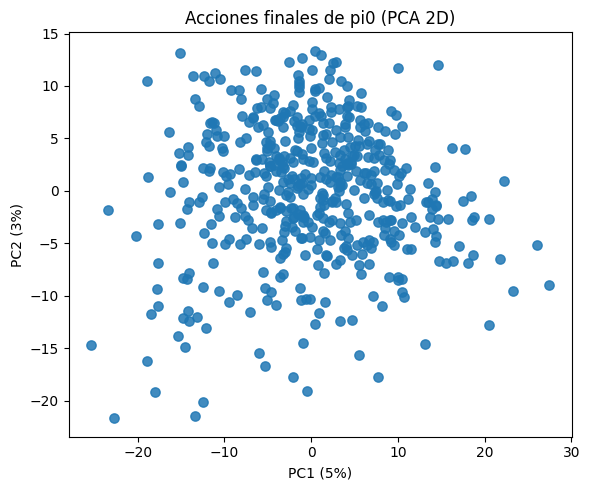

In [54]:
fm.plot_pca()

## 4. ¿Cuántos clusters? KMeans + silhouette

Probamos varios `k` y medimos el *silhouette score* (qué tan separados y compactos
son los clusters). Regla práctica:

| silhouette | lectura |
|---|---|
| > 0.50 | estructura de clusters **fuerte** |
| 0.25 – 0.50 | estructura **débil** |
| < 0.25 | **sin** clusters claros (salida ~unimodal / continua) |

silhouette por k: {2: np.float64(0.026), 3: np.float64(0.021), 4: np.float64(0.017), 5: np.float64(0.016), 6: np.float64(0.013)}
mejor k = 2  (silhouette = 0.026)


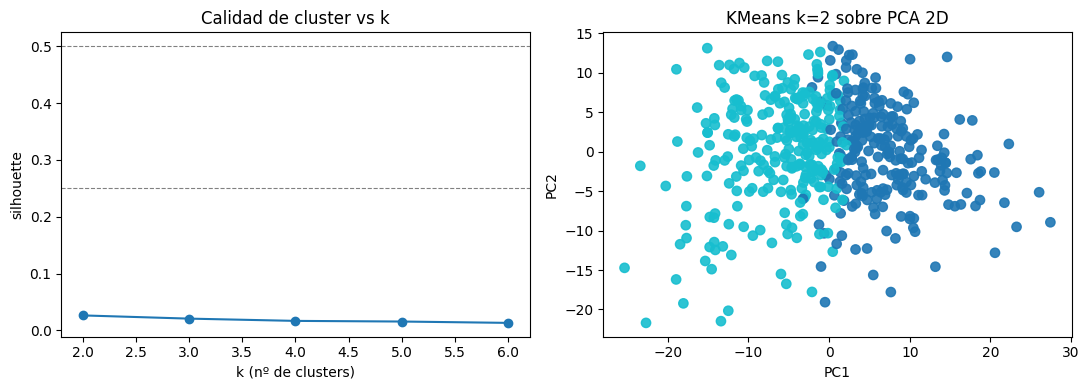

In [55]:
fm.plot_kmeans()

## 5. t-SNE (no lineal)

PCA es lineal; t-SNE puede revelar clusters que PCA no separa. Coloreamos con los
clusters de KMeans para comparar. La `perplexity` se ajusta al nº de muestras.

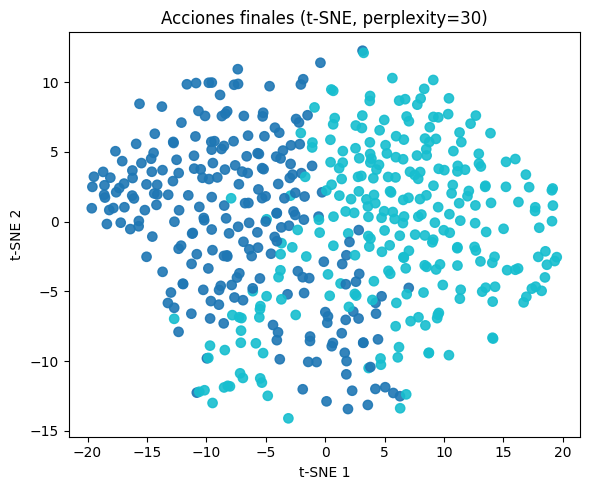

In [56]:
fm.plot_tsne()

## 6. Cómo el ruido colapsa hacia las acciones finales

Proyectamos **todas** las iteraciones con una PCA común y dibujamos la trayectoria
de cada corrida: del ruido inicial (rojo, iteración 0) a la acción final (azul).
Si los puntos azules se agrupan en zonas separadas, hay clusters al final.

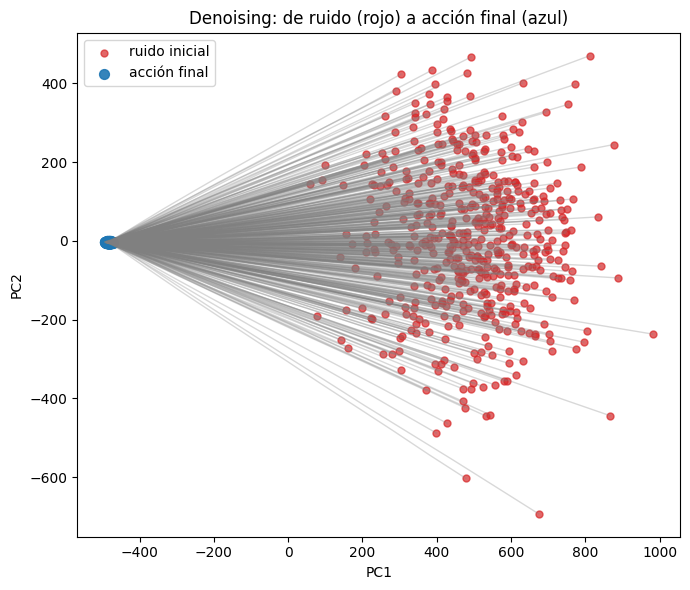

In [57]:
fm.plot_trajectories()

## 7. Conclusión

Junta las tres señales:
- **Silhouette** (celda 4): si el mejor `k` supera ~0.5, hay clusters marcados.
- **Dispersión 2D** (PCA / t-SNE): grupos visualmente separados vs. una nube única.
- **Trayectorias** (celda 6): si los puntos azules aterrizan en zonas distintas.

Si no hay clusters claros, la política es prácticamente **unimodal** para ese
input. Si los hay, es **multimodal**: distintas corridas eligen estrategias
distintas desde el mismo estado.

## 8. Animación (GIF) del flow-matching

Un frame por iteración: muestra cómo se mueven los vectores en el plano PCA desde
el **ruido inicial** (iteración 0) hasta las **acciones finales**. Cada punto se
colorea por el cluster al que llega, para ver cómo emergen los grupos.

Guarda el GIF en `output/pi0_denoise/flow_matching.gif` y lo muestra inline.

GIF guardado en: output/pi0_denoise/flow_matching.gif


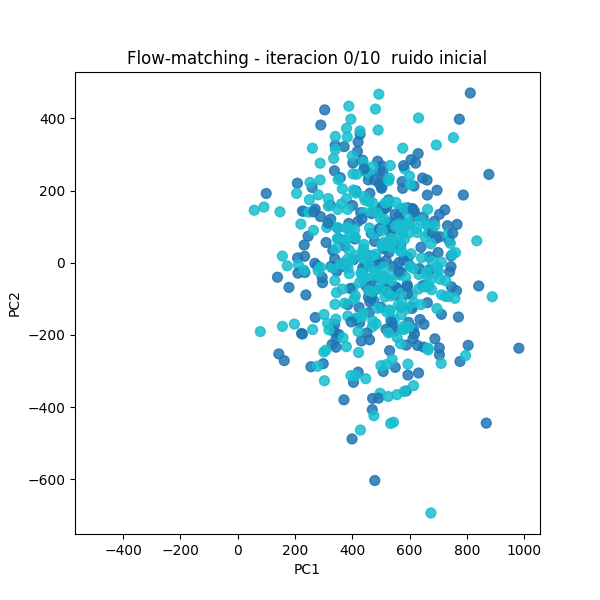

In [58]:
fm.save_gif("output/pi0_denoise/flow_matching.gif")

## 9. UMAP: detección de clusters de los vectores finales

UMAP suele separar clusters no lineales mejor que PCA/t-SNE. Ajustamos UMAP sobre
las **acciones finales** y detectamos clusters en ese embedding (KMeans +
*silhouette*). Este `reducer` se reutiliza luego para el GIF, así el último frame
coincide con este scatter.

> Requiere **`umap-learn`** en el entorno `tipico`:  `pip install umap-learn`.

c:\Users\diego\anaconda3\envs\tipico\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


silhouette (UMAP) por k: {2: np.float32(0.395), 3: np.float32(0.398), 4: np.float32(0.388), 5: np.float32(0.39), 6: np.float32(0.382)}
mejor k = 3  (silhouette = 0.398)


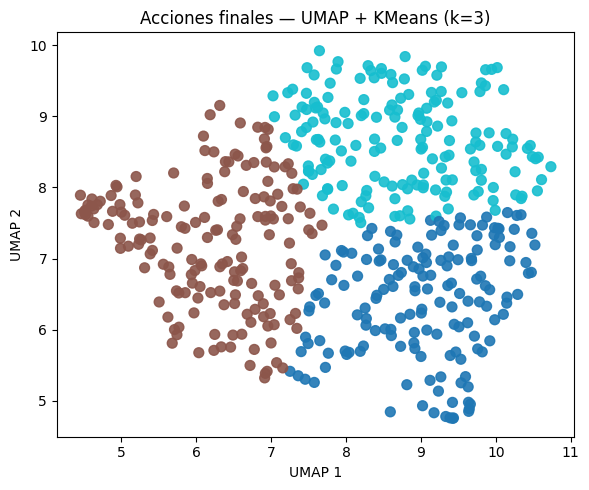

In [59]:
# Requiere umap-learn:  pip install umap-learn
U, scan_umap = fm.plot_umap()

## 10. GIF del flow-matching en espacio UMAP

Proyectamos **todas** las iteraciones al MISMO espacio UMAP de las finales
(`reducer.transform`) y animamos iteración a iteración. Así el ruido inicial
aparece mapeado dentro del layout de clusters y se ve cómo colapsa hacia ellos;
el último frame coincide con el scatter de la celda 9.

Nota: UMAP es no lineal, así que las trayectorias pueden verse menos suaves que
en PCA (el GIF de la sección 8). UMAP prioriza separar clusters, no preservar el
camino lineal del denoising.

## 11. Estudio por `step`: ¿algún paso es multimodal?

Repite el análisis de clusters de las **acciones finales**, pero **por cada `step`**
del entorno (cada estado en el que se generaron las `N_SAMPLES` muestras). Así
detectamos si la política se vuelve multimodal en ciertos estados.

Para cada step: tomamos las acciones finales (última iteración de cada `call`),
buscamos el mejor `k` con *silhouette* y clasificamos el step como:
**fuerte** (silhouette > 0.50), **débil** (0.25–0.50) o **unimodal** (< 0.25).

In [60]:
study = PerStepStudy(log)
study.summary()

Resumen por step:
        n  best_k  best_sil veredicto
step                                 
0     100       2     0.025  unimodal
1     100       2     0.020  unimodal
2     100       2     0.050  unimodal
3     100       2     0.021  unimodal
4     100       2     0.052  unimodal

Steps con indicios de multimodalidad: ninguno


,n,best_k,best_sil,veredicto
step,,,,
0,100,2,0.025,unimodal
1,100,2,0.020,unimodal
2,100,2,0.050,unimodal
3,100,2,0.021,unimodal
4,100,2,0.052,unimodal


### Silhouette por step

Barras sobre la línea 0.50 = clusters fuertes (multimodal claro); entre 0.25 y
0.50 = estructura débil. Encima de cada barra, el mejor `k`.

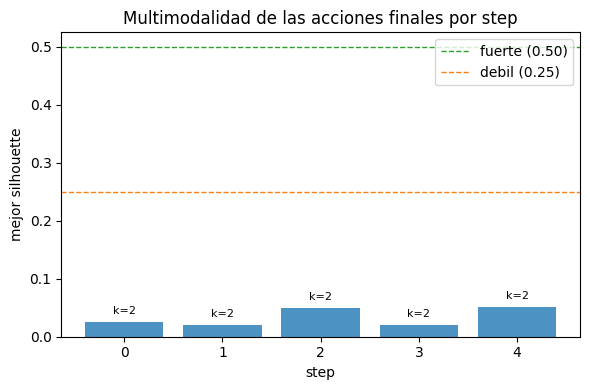

In [61]:
study.plot_silhouette()

### Proyección 2D (PCA) por step

Una PCA independiente por step, coloreada por los clusters de KMeans (con el mejor
`k` de ese step). Confirma visualmente dónde hay grupos separados.

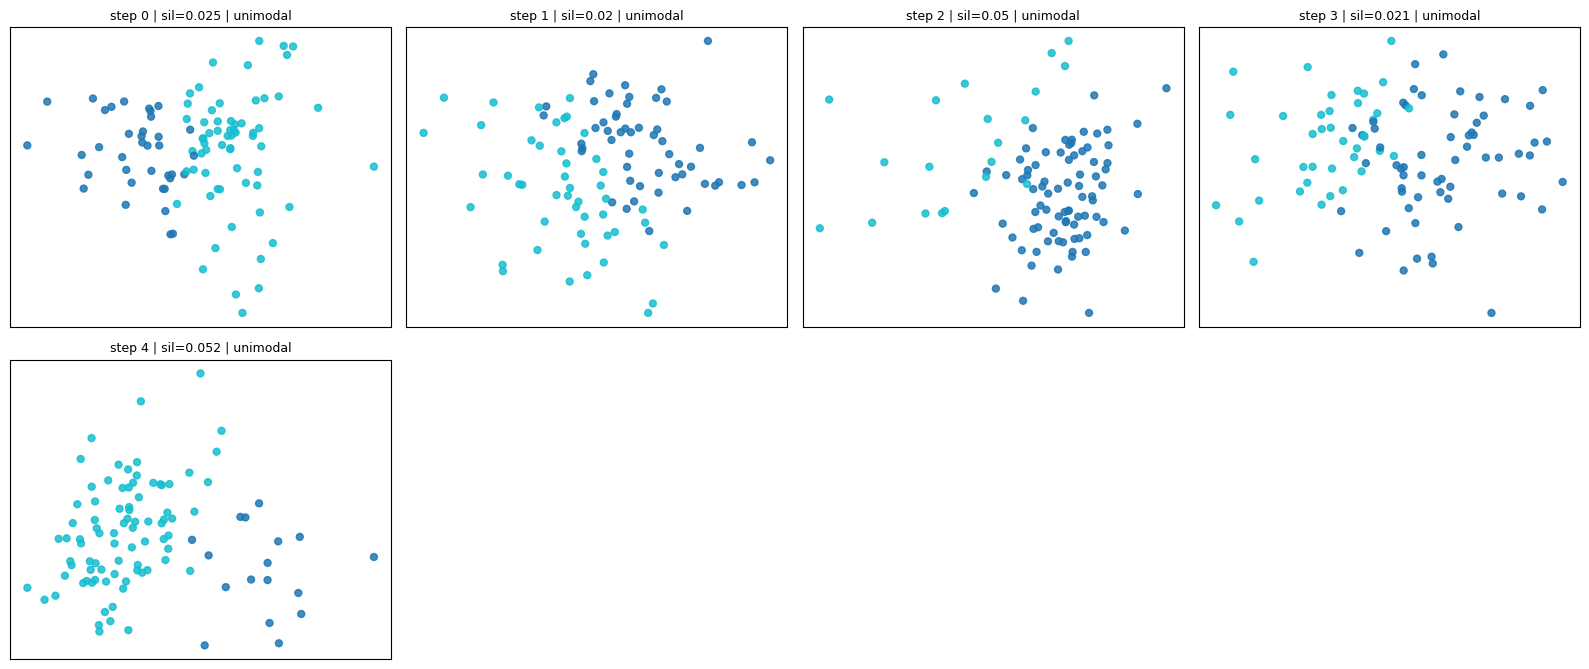

In [62]:
study.plot_pca_grid()

### GIF del flow-matching por step (guardados en carpeta)

Genera un GIF del denoising **por cada `step`** y los guarda por separado en
`output/pi0_denoise/gifs_por_step/` (`step_00.gif`, `step_01.gif`, …). Cada GIF
usa el PCA propio de ese step y colorea las corridas por su cluster final, así se
ve cómo colapsa el ruido hacia las acciones en ese estado concreto.

  GIF step 0 -> output/pi0_denoise/gifs_por_step\step_00.gif
  GIF step 1 -> output/pi0_denoise/gifs_por_step\step_01.gif
  GIF step 2 -> output/pi0_denoise/gifs_por_step\step_02.gif
  GIF step 3 -> output/pi0_denoise/gifs_por_step\step_03.gif
  GIF step 4 -> output/pi0_denoise/gifs_por_step\step_04.gif

5 GIFs guardados en output/pi0_denoise/gifs_por_step/


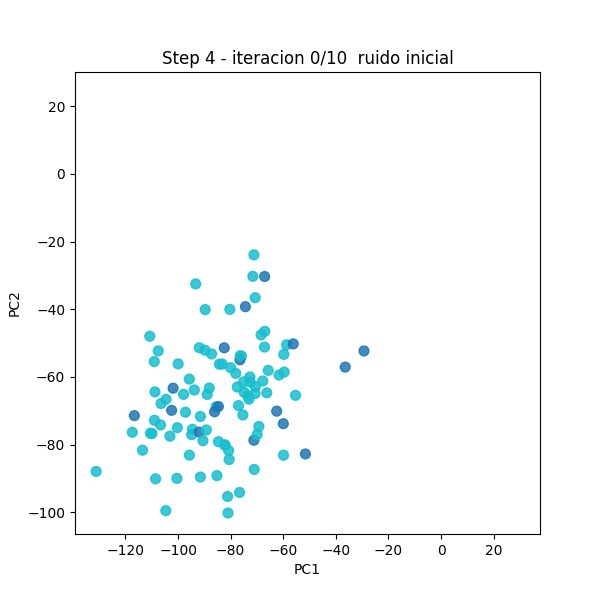

In [63]:
# Un GIF del denoising por cada step, guardados en la carpeta indicada.
gif_paths = study.save_gifs("output/pi0_denoise/gifs_por_step")

# (opcional) Previsualizar uno inline, p. ej. el primer step multimodal:
from IPython.display import Image
Image(filename=gif_paths[-1]) if gif_paths else None

## 12. CSV: desviación estándar por coordenada (no-padding)

Genera un **CSV nuevo** con la desviación estándar de cada coordenada de la
**acción final** (última iteración del denoising), calculada **sobre todas las
corridas**. Solo incluye coordenadas **no-padding**: el vector es
`(chunk_size, max_action_dim)` aplanado y pi0 rellena hasta `max_action_dim=32`,
pero LIBERO usa solo `action_dim=7` reales por paso del chunk (6 cartesianas +
pinza), así que las dims 7–31 de cada bloque se descartan.

Columnas: `coordenada`, `indice`, `chunk_step`, `dim`, `media`, `std`,
`pct_del_max_std` (std como % del máximo std entre coordenadas) y `pct_del_max_abs`
(std como % del |valor| máximo de esa coordenada). Se guarda en
`output/pi0_denoise/std_por_coordenada.csv`.

> Para un desglose **por step** (una fila por `step`×coordenada) usa
> `study.std_report("output/pi0_denoise/std_por_coordenada_por_step.csv")`.

In [64]:
# std por coordenada (no-padding) de las acciones finales, sobre TODAS las corridas.
# action_dim=7 (LIBERO: 6 cartesianas + pinza), max_action_dim=32 (padding de pi0).
std_df = fm.std_report("output/pi0_denoise/std_por_coordenada.csv",
                       action_dim=7, max_action_dim=32)
std_df.head(10)

CSV guardado en: output/pi0_denoise/std_por_coordenada.csv
coordenadas no-padding: 350 de 1600  (chunk_size=50, action_dim=7, max_action_dim=32)
std max = 0.6989  (coord v1574)

Top-5 coordenadas por std:
coordenada  indice  chunk_step  dim     media      std  pct_del_max_std  pct_del_max_abs
     v1574    1574          49    6 -0.675798 0.698933       100.000000        65.590486
     v1542    1542          48    6 -0.770260 0.580183        83.009772        53.992815
     v1510    1510          47    6 -0.830382 0.485142        69.411760        44.915639
      v577     577          18    1 -1.168130 0.392026        56.089282        19.084368
      v609     609          19    1 -1.047554 0.388958        55.650312        20.170604


,coordenada,indice,chunk_step,dim,media,std,pct_del_max_std,pct_del_max_abs
0,v0,0,0,0,-0.057533,0.023216,3.321570,20.128432
1,v1,1,0,1,-0.926306,0.339156,48.524819,19.996027
2,v2,2,0,2,0.209072,0.013584,1.943587,5.577976
3,v3,3,0,3,-0.003930,0.015149,2.167456,9.387859
4,v4,4,0,4,0.064158,0.135428,19.376416,27.335865
5,v5,5,0,5,0.054957,0.024774,3.544615,22.367035
6,v6,6,0,6,-0.951724,0.006662,0.953225,0.685811
7,v32,32,1,0,-0.055782,0.025025,3.580400,20.165031
8,v33,33,1,1,-1.014083,0.355084,50.803715,19.893728
9,v34,34,1,2,0.201528,0.014330,2.050271,5.900476


## 13. CSV en unidades físicas (cm / grados)

Igual que la sección 12, pero **des-normalizando** para escribir el CSV directamente
en **unidades físicas**: posición (dims 0–2) en **cm**, orientación (dims 3–5) en
**grados**, y pinza (dim 6) como comando. Se guarda en
`output/pi0_denoise/std_por_coordenada_cm.csv`.

**Requisito (una sola vez):** las coordenadas del CSV de denoising están en espacio
*normalizado*, así que hay que des-normalizarlas con las estadísticas del checkpoint.
Genera ese JSON una vez en el entorno **`pizero`** (con GPU y el checkpoint):

```bash
conda run -n pizero python scripts/export_action_stats.py
```

Eso escribe `output/pi0_denoise/action_norm_stats.json`, que esta celda usa para
convertir. La conversión es: `comando = norm·unnorm_std + unnorm_mean`, y luego el
controlador OSC_POSE de LIBERO escala el comando a físico (posición ×0.05 m → cm,
orientación ×0.5 rad → grados). `pct_del_max_std` se calcula **dentro de cada
unidad** (cm con cm, grados con grados), porque comparar cm contra grados no aplica.

In [ ]:
# CSV en UNIDADES FISICAS: posicion en cm, orientacion en grados, pinza como comando.
# Requiere haber generado las stats UNA vez en el entorno pizero:
#     conda run -n pizero python scripts/export_action_stats.py
std_cm = fm.std_report_cm("output/pi0_denoise/std_por_coordenada_cm.csv",
                          action_dim=7, max_action_dim=32)
std_cm.head(10)